<h1> Compare Strategies

Comparison Objective
We aim to answer the following questions:
- Which algorithm learns faster?
- Which algorithm incurs less regret?
- Which method performs better exploration?
- What are the differences between Random, Uncertainty-based, and Bayesian methods?

For a fair comparison, the following are required:
- The environment must be identical.
- The number of steps must be the same.
- The experiments must be run multiple times.

This is because the bandit is stochastic;
running it only once could lead to a result based on chance.

<h3> Step 1: Imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.bandit import (
    MultiArmedBandit,
    EpsilonGreedyAgent,
    EpsilonDecayAgent,
    UCBAgent
)

<h3> Step 2: Build Environment

for Gaussian Bandit:

In [11]:
np.random.seed(42)

bandit = MultiArmedBandit(
    n_arms=10
)

best_mean = np.max(
    bandit.means
)

print("True values:")
print(bandit.means)

print("\nBest arm:")
print(np.argmax(bandit.means))

True values:
[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004]

Best arm:
6


<h3> Step 3: Agent execution function

In [12]:
def run_experiment(
    bandit,
    agent,
    steps=5000
):

    rewards = []
    actions = []

    for _ in range(steps):

        action = agent.select_action()

        reward = bandit.step(
            action
        )

        agent.update(
            action,
            reward
        )

        rewards.append(reward)
        actions.append(action)

    return np.array(rewards), np.array(actions)

<h3> Step 4: Defining Agents

In [13]:
agents = {

    "Epsilon Greedy":
    EpsilonGreedyAgent(
        n_arms=10,
        epsilon=0.1
    ),


    "Epsilon Decay":
    EpsilonDecayAgent(
        n_arms=10,
        epsilon=1.0,
        decay=0.995,
        min_epsilon=0.01
    ),


    "UCB":
    UCBAgent(
        n_arms=10,
        c=2
    )
}

<h3> Step 5: Execution of all agents

In [14]:
results = {}

for name, agent in agents.items():

    rewards, actions = run_experiment(
        bandit,
        agent,
        steps=5000
    )

    results[name] = {
        "rewards": rewards,
        "actions": actions
    }

<h3> Step 6: Average Reward Comparison

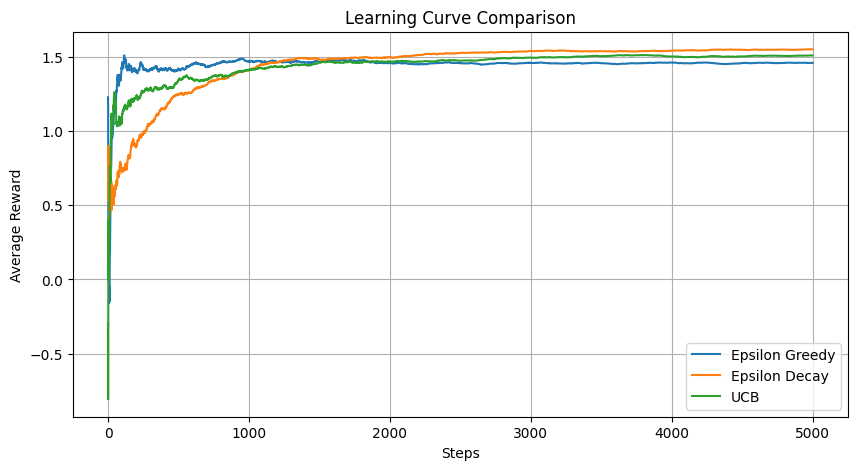

In [15]:
plt.figure(figsize=(10,5))


for name, data in results.items():

    rewards = data["rewards"]

    avg_reward = (
        np.cumsum(rewards)
        /
        np.arange(
            1,
            len(rewards)+1
        )
    )

    plt.plot(
        avg_reward,
        label=name
    )


plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title(
    "Learning Curve Comparison"
)

plt.legend()
plt.grid()

plt.show()

Learning Curve Comparison Results

This chart displays the Average Reward over time. There are three main behaviors:

1. Epsilon-Greedy (Blue)

Behavior:
- Rises very quickly at the start of training.
- Surpasses the others within just the first few hundred steps.
- However, it eventually plateaus.

Reason:
In ε-Greedy:
epsilon = 0.1

This means that even after the agent has identified the best arm, it still makes a random choice 10% of the time.
Consequently:
- It learns quickly.
- But it retains some residual exploration at the end.

2. Epsilon-Decay (Orange)

The best result in this experiment.

Behavior: Initially slightly slower than ε-Greedy, because starting with epsilon = 1 implies intense exploration.
However, the agent gradually shifts to relying primarily on the information it has learned.

Result:
- Good exploration at the start.
- Strong exploitation at the end.

This is why it achieved the highest Average Reward.

3. UCB (Green)

Very close to ε-Decay.
Behavior:
- Starts somewhat more slowly.
- Eventually converges on the best arm.

Reason:
UCB does not rely on random exploration.
Instead, it considers the Value plus an Uncertainty Bonus.
This means it prioritizes examining arms about which it has little information.

Result:
##### $ε-Decay > UCB > ε-Greedy$

<h3> Step 7: Cumulative Regret Comparison

In [16]:
regrets = {}


for name, data in results.items():

    actions = data["actions"]


    chosen_means = np.array([
        bandit.means[a]
        for a in actions
    ])


    instant_regret = (
        best_mean
        -
        chosen_means
    )


    regrets[name] = np.cumsum(
        instant_regret
    )

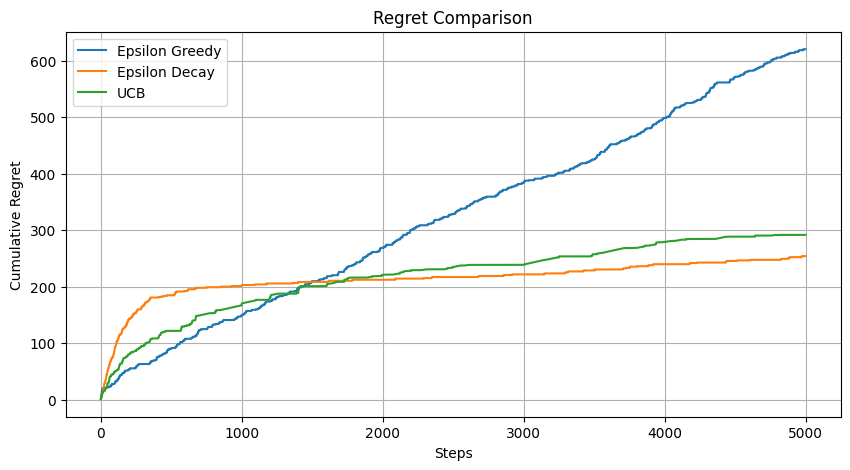

In [17]:
plt.figure(figsize=(10,5))


for name, regret in regrets.items():

    plt.plot(
        regret,
        label=name
    )


plt.xlabel("Steps")
plt.ylabel(
    "Cumulative Regret"
)

plt.title(
    "Regret Comparison"
)

plt.legend()
plt.grid()

plt.show()

Regret Comparison Results

This chart is more important than the previous one because it illustrates the cost of exploration.

1. Epsilon-Greedy

Worst performance.

Reason:
Even after learning has occurred,
10% random action
continues.

Consequently, over the course of 5,000 steps,
suboptimal arms are selected repeatedly.

2. Epsilon-Decay

Best performance.
Because it prioritizes exploration initially, followed by exploitation.

This means exploration occurs only when it is worthwhile.

3. UCB

Slightly higher regret than ε-Decay,
but still far superior to ε-Greedy.

UCB Behavior:

Initially explores based on uncertainty,
then focuses on the better arm.

<h3> Step 8: Final Performance Table

In [18]:
summary = []


for name, data in results.items():

    rewards = data["rewards"]

    summary.append({

        "Algorithm": name,

        "Final Average Reward":
        np.mean(
            rewards[-500:]
        ),

        "Final Cumulative Regret":
        regrets[name][-1]
    })


comparison_df = pd.DataFrame(
    summary
)

comparison_df

,Algorithm,Final Average Reward,Final Cumulative Regret
0,Epsilon Greedy,1.470430,620.072561
1,Epsilon Decay,1.587061,254.167480
2,UCB,1.569131,291.720125


### Bandit Strategy Comparison

Three exploration strategies were evaluated on the same multi-armed bandit environment:

- Epsilon Greedy
- Epsilon Decay Greedy
- Upper Confidence Bound (UCB)

The results show that fixed epsilon-greedy achieves fast initial learning but suffers from unnecessary exploration in later stages, resulting in higher cumulative regret.

Epsilon decay provides a better exploration-exploitation balance by allowing more exploration at the beginning and gradually focusing on the best actions.

UCB also performs well by replacing random exploration with uncertainty-based exploration.

In this experiment, epsilon decay achieved the highest final reward and the lowest cumulative regret, demonstrating the importance of adapting exploration during learning.